# WESM Price Prediction - Model 3: Neural Network

## Setup and Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15260 entries, 0 to 15259
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            15260 non-null  datetime64[ns]
 1   GWAP                15260 non-null  float64       
 2   energy_demand_mw    15260 non-null  float64       
 3   energy_supply_mw    15260 non-null  float64       
 4   energy_shortage_mw  15260 non-null  float64       
 5   reserve_demand_mw   15260 non-null  float64       
 6   reserve_supply_mw   15260 non-null  float64       
 7   outage_count        15260 non-null  float64       
 8   GWAP_Lag_1          15260 non-null  float64       
 9   GWAP_Lag_12         15260 non-null  float64       
 10  GWAP_Lag_288        15260 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 1.3 MB
None


First we need to ensure consistency across all data types to be able to use Tensor later on. So, we will convert the `month_year` feature into a datetime variable and separate them into two categories: `month` and `year`.

In [2]:
df["month_year"] = df["datetime"].dt.to_period("M").astype(str)

# Convert string to datetime
df['date_col'] = pd.to_datetime(df['month_year'], format='%Y-%m')

df['year'] = df['date_col'].dt.year
df['month'] = df['date_col'].dt.month

`X_gwap` will contain all the features aside from `GWAP` and `gwap_range` as those will serve as our label. Time-based columns are also dropped since we have already made separate columns for `year` and `month`. `y_gwap` will contain the GWAP and serve as our label.

In [3]:
# remove datetime since we already have separate columns
X_gwap = df.drop(["GWAP", "datetime", "month_year", "date_col"], axis=1)

# Transforms the class variable into a matrix of shape (n_samples, 1)
y_gwap = df["GWAP"].values

X_gwap.head()

,energy_demand_mw,energy_supply_mw,energy_shortage_mw,reserve_demand_mw,reserve_supply_mw,outage_count,GWAP_Lag_1,GWAP_Lag_12,GWAP_Lag_288,year,month
0,8549.80,8592.66,-42.86,1368.0,1368.0,3.0,3127.6873,2528.3538,2321.6376,2025,11
1,8502.47,8621.92,-119.45,1368.0,1368.0,3.0,2590.3569,2534.1721,2394.5301,2025,11
2,8503.43,8621.24,-117.81,1368.0,1368.0,3.0,2379.0282,2484.7641,2325.4293,2025,11
3,8446.04,8586.57,-140.53,1368.0,1368.0,3.0,2378.7328,2720.1748,2320.9318,2025,11
4,8474.76,8589.58,-114.82,1368.0,1368.0,3.0,2378.4848,2756.0153,2314.6513,2025,11


In [4]:
y_gwap

array([2590.3569, 2379.0282, 2378.7328, ..., 2831.0809, 2830.2625,
       2730.0929], shape=(15260,))

## Splitting the Data

Dividing the dataset into training set, validation set, and test set. The test and validation set will contain 15% of the original dataset, while the training set will contain 70%.

In [5]:
from sklearn.model_selection import train_test_split

# Separate the test set from the train and validation sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_gwap,
    y_gwap,
    test_size=0.15,
    random_state=1,
    shuffle=True
)

# Separate the validation set from the train set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.17647,  # 15% of leftover data
    random_state=1,
    shuffle=True
)

In [6]:
print("Size of training set: ", X_train.shape)
print("Size of validation set: ", X_val.shape)
print("Size of test set: ", X_test.shape)

Size of training set:  (10682, 11)
Size of validation set:  (2289, 11)
Size of test set:  (2289, 11)


## Standardizing the Data

Since we are working with high-magnitude values, we will standardize our data to lessen the probability of overshooting. We will only fit on training data to prevent data leakage.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
X_test = scaler_X.transform(X_test)
X_val = scaler_X.transform(X_val)  

In [8]:
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
y_test = scaler_y.transform(y_test.reshape(-1, 1))
y_val = scaler_y.transform(y_val.reshape(-1, 1))

## Converting to Tensor

Convert the np.ndarrays to datatype torch.Tensor

In [9]:
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)
X_val = torch.Tensor(X_val)
y_val = torch.Tensor(y_val)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)

torch.Size([10682, 11])
torch.Size([10682, 1])
torch.Size([2289, 11])
torch.Size([2289, 1])
torch.Size([2289, 11])
torch.Size([2289, 1])


## Setting up the Neural Network

*Hyperparameter tuning to be done later, this is just to see how it works with a random model

*nn will be coded manually, this is just for testing

First, we import the NeuralNetwork class

In [10]:
from neural_network import NeuralNetwork

In [ ]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [64, 32]      # to be tuned
output_size = 1

# layers = []
# in_dim = input_size
# 
# for h in hidden_layers:
#     layers.append(nn.Linear(in_dim, h))
#     layers.append(activation())
#     in_dim = h
# layers.append(nn.Linear(in_dim, output_size))
# 
# model = nn.Sequential(*layers)

model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation='relu')

print(model.layers)

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU(inplace=True)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU(inplace=True)
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [20]:
model.create_network()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [21]:
model.init_weights()
print(model.layers[0].weight)

Parameter containing:
tensor([[-1.0408e-01,  9.1660e-02, -1.3042e-01, -1.1097e-01, -1.2188e-01,
          1.1676e-01, -1.0574e-01, -1.1884e-02, -9.0784e-02,  3.4522e-02,
         -5.7133e-02],
        [-2.3511e-02,  1.0076e-01, -7.5288e-02, -2.2500e-02, -4.3269e-02,
         -1.5071e-01, -4.5856e-02, -8.4800e-02,  5.2660e-02,  2.9916e-03,
         -4.9838e-03],
        [ 1.0651e-01,  8.8604e-02,  4.6402e-02, -4.9863e-02,  1.2886e-02,
          2.7631e-01,  1.4048e-02,  1.1191e-01,  3.1523e-02,  1.7528e-01,
         -7.6496e-02],
        [ 1.8299e-01, -2.7840e-02, -2.7195e-02, -1.2944e-01, -2.4313e-03,
         -2.3536e-02, -7.0871e-02,  1.1566e-01,  4.2960e-02, -1.1874e-01,
         -7.4678e-02],
        [-9.3198e-02, -8.5786e-02, -9.6473e-02, -9.9146e-03, -1.0190e-01,
          3.1568e-02, -1.6036e-01,  1.8493e-01,  4.4727e-03,  1.5853e-01,
         -5.9122e-02],
        [ 1.1312e-01,  7.5621e-02, -1.2023e-01, -5.8335e-02, -4.4069e-02,
         -1.9791e-01,  7.7871e-02, -7.7485e-02, -

In [22]:
print(model.layers[0].bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)


## Loss and Optimizer

In [12]:
# used for regression
criterion = nn.MSELoss()  
learning_rate = 0.001      # to be tuned
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training

In [ ]:
epochs = 200   # to be tuned
# batch_size = 32  # to be tuned
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()

    # Empty the gradients of the network.
    optimizer.zero_grad()
    
    # Forward propagation
    y_pred = model(X_train) # calls the forward method but adding gradient tracking, hooks, extra support
    
    # Compute the loss
    loss = criterion(y_pred, y_train)
    
    # Backward propagation
    loss.backward()

    # Update parameters
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

Epoch 0: Train Loss=0.9862, Val Loss=0.9881
Epoch 20: Train Loss=0.6150, Val Loss=0.6488
Epoch 40: Train Loss=0.3718, Val Loss=0.4418
Epoch 60: Train Loss=0.2579, Val Loss=0.3530
Epoch 80: Train Loss=0.2033, Val Loss=0.2934
Epoch 100: Train Loss=0.1779, Val Loss=0.2637
Epoch 120: Train Loss=0.1687, Val Loss=0.2545
Epoch 140: Train Loss=0.1645, Val Loss=0.2509
Epoch 160: Train Loss=0.1623, Val Loss=0.2491
Epoch 180: Train Loss=0.1608, Val Loss=0.2481


## Hyperparameter Tuning

...

## Evaluation

In [14]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

# inverse-transform the predictions to get them back to the original scale
y_pred_original = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_original = scaler_y.inverse_transform(y_test.numpy())

In [15]:
print(y_pred_test.shape)
print(y_test.shape)
print(scaler_y.n_features_in_)

torch.Size([2289, 1])
torch.Size([2289, 1])
1


In [16]:
print(y_test_original.shape)
print(y_pred_original.shape)

(2289, 1)
(2289, 1)


Visualization

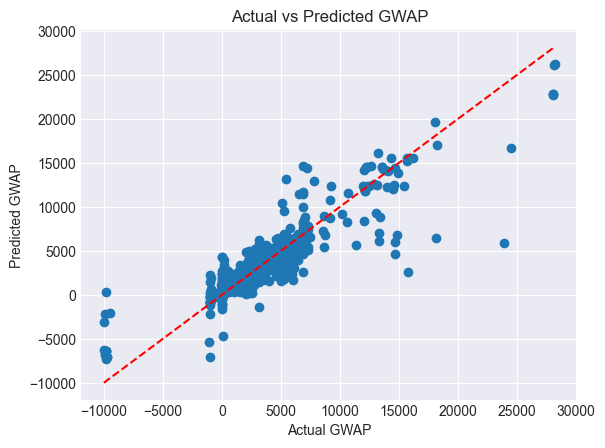

In [17]:
plt.scatter(y_test_original, y_pred_original)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test_original), max(y_test_original)],
         [min(y_test_original), max(y_test_original)],
         'r--')  # perfect prediction line
plt.show()

Text(0.5, 1.0, 'Loss for each training epoch')

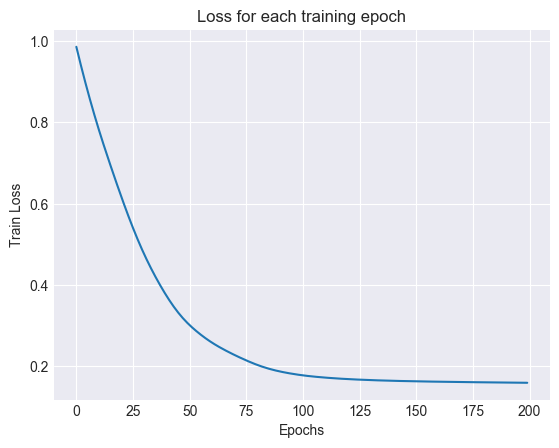

In [18]:
x_values = [i for i in range(len(train_losses))]
y_values = train_losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.title('Loss for each training epoch')

Text(0.5, 1.0, 'Loss for each validation epoch')

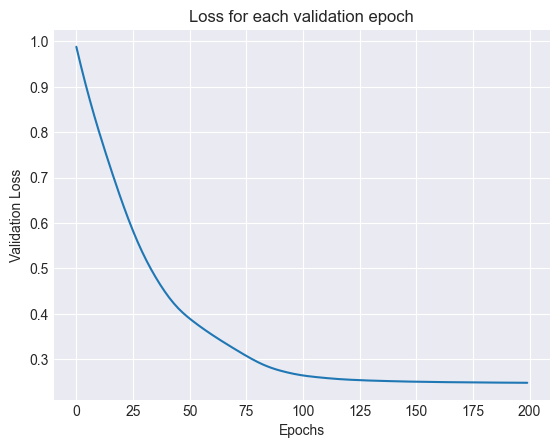

In [19]:
x_values = [i for i in range(len(val_losses))]
y_values = val_losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Loss for each validation epoch')